# HLT Project —  Dataset Preparation

## Research Question

What linguistic signals do humans and automated models use to detect textual deception, and how do they differ?
## Objective

The goal of this part is to obtain a clean, reproducible and well-understood dataset before running any automatic model.

The positive subset of the Deceptive Opinion Spam Corpus is used :
- 400 truthful positive reviews
- 400 deceptive positive reviews
- 20 Chicago hotels
- 5 original hotel folds

## 1. Project Setup and Persistent Storage

In [ ]:
from google.colab import drive
from pathlib import Path

import pandas as pd
import numpy as np
import random


# Mount Google Drive.
drive.mount("/content/drive")


# Reproducibility.
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# Main project folders.
PROJECT_DIR = Path(
    "/content/drive/MyDrive/HLT_project"
)

DATA_DIR = PROJECT_DIR / "data"

RAW_DATA_DIR = DATA_DIR / "raw"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

METADATA_DIR = DATA_DIR / "metadata"

SAMPLES_DIR = PROJECT_DIR / "samples"

RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR = PROJECT_DIR / "figures"


# Create folders if they do not exist.
for folder in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    METADATA_DIR,
    SAMPLES_DIR,
    RESULTS_DIR,
    FIGURES_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("Project directory:", PROJECT_DIR)
print("Random seed:", RANDOM_SEED)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/HLT_project
Random seed: 42


## 2. Load the Deceptive Opinion Spam Corpus

In [ ]:
!pip -q install kagglehub

In [ ]:
import kagglehub
import shutil


RAW_CSV_PATH = (
    RAW_DATA_DIR /
    "deceptive-opinion.csv"
)


# Download the corpus only if it is not already
# stored permanently on Google Drive.
if not RAW_CSV_PATH.exists():

    print("Downloading dataset...")

    downloaded_path = kagglehub.dataset_download(
        "rtatman/deceptive-opinion-spam-corpus",
        path="deceptive-opinion.csv"
    )

    shutil.copy2(
        downloaded_path,
        RAW_CSV_PATH
    )

    print("Dataset downloaded and saved on Drive.")

else:

    print("Dataset already available on Drive.")


# Load the complete corpus.
reviews = pd.read_csv(
    RAW_CSV_PATH
)


print("Dataset shape:", reviews.shape)

print("\nColumns:")
print(reviews.columns.tolist())


display(
    reviews.head()
)

100%|██████████| 456k/456k [00:00<00:00, 586kB/s]

Extracting zip of deceptive-opinion.csv...
Dataset downloaded and saved on Drive.
Dataset shape: (1600, 5)

Columns:
['deceptive', 'hotel', 'polarity', 'source', 'text']


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


## 3. Select the Positive Reviews

In [ ]:
positive_reviews = reviews[
    reviews["polarity"] == "positive"
].copy()


positive_reviews = positive_reviews.reset_index(
    drop=True
)


print(
    "Number of positive reviews:",
    len(positive_reviews)
)


print("\nLABEL DISTRIBUTION")

display(
    positive_reviews[
        "deceptive"
    ].value_counts()
)


print("\nSOURCE DISTRIBUTION")

display(
    positive_reviews[
        "source"
    ].value_counts()
)


print("\nLABEL × SOURCE")

display(
    pd.crosstab(
        positive_reviews["deceptive"],
        positive_reviews["source"]
    )
)

Number of positive reviews: 800

LABEL DISTRIBUTION


,count
deceptive,
truthful,400
deceptive,400



SOURCE DISTRIBUTION


,count
source,
TripAdvisor,400
MTurk,400



LABEL × SOURCE


source,MTurk,TripAdvisor
deceptive,,
deceptive,400,0
truthful,0,400


## 4. Recover the Original Hotel Folds

In [ ]:
import requests
import gzip
import tarfile
import io


FOLD_MAP_PATH = (
    METADATA_DIR /
    "hotel_fold_map.csv"
)


if FOLD_MAP_PATH.exists():

    # If we have already created the fold map,
    # simply load it from Drive.

    hotel_fold_map = pd.read_csv(
        FOLD_MAP_PATH
    )

    print("Fold map loaded from Drive.")


else:

    print("Recovering original fold information...")


    ACL_DATASET_URL = (
        "https://aclanthology.org/"
        "anthology-files/anthology-files/"
        "attachments/P/P11/"
        "P11-1032.Datasets.zip"
    )


    response = requests.get(
        ACL_DATASET_URL,
        timeout=60
    )

    response.raise_for_status()


    archive_data = response.content


    # The ACL attachment is delivered with
    # an additional GZIP compression layer.
    if archive_data[:2] == b"\x1f\x8b":

        archive_data = gzip.decompress(
            archive_data
        )


    fold_rows = []


    # Read the TAR archive directly in memory.
    with tarfile.open(
        fileobj=io.BytesIO(archive_data),
        mode="r:*"
    ) as archive:

        for member in archive.getmembers():

            if not member.isfile():
                continue

            if not member.name.endswith(
                ".uni.txt"
            ):
                continue


            path_parts = Path(
                member.name
            ).parts


            source = path_parts[-3]

            fold = path_parts[-2]

            file_name = path_parts[-1]


            if source not in [
                "TripAdvisor",
                "MTurk"
            ]:
                continue


            # Example:
            # t_swissotel_17.uni.txt
            #
            # becomes:
            # swissotel

            clean_name = (
                file_name
                .removesuffix(".uni.txt")
            )

            clean_name = clean_name[2:]

            hotel = clean_name.rsplit(
                "_",
                1
            )[0]


            fold_rows.append({
                "hotel": hotel,
                "fold": fold
            })


    hotel_fold_map = (
        pd.DataFrame(fold_rows)
        .drop_duplicates()
        .sort_values(
            ["fold", "hotel"]
        )
        .reset_index(drop=True)
    )


    # Check that one hotel never belongs
    # to more than one fold.
    folds_per_hotel = (
        hotel_fold_map
        .groupby("hotel")["fold"]
        .nunique()
    )


    assert (
        folds_per_hotel.max() == 1
    )


    # Keep one row per hotel.
    hotel_fold_map = (
        hotel_fold_map
        .drop_duplicates(
            subset="hotel"
        )
        .reset_index(drop=True)
    )


    hotel_fold_map.to_csv(
        FOLD_MAP_PATH,
        index=False
    )


    print("Fold map created and saved.")


display(
    hotel_fold_map
)

Recovering original fold information...
Fold map created and saved.


,hotel,fold
0,hilton,fold1
1,james,fold1
2,monaco,fold1
3,sofitel,fold1
4,affinia,fold2
5,ambassador,fold2
6,hardrock,fold2
7,talbott,fold2
8,conrad,fold3
9,fairmont,fold3


## 5. Verify the Original Fold Structure

In [ ]:
print(
    "Number of hotels:",
    hotel_fold_map["hotel"].nunique()
)


print(
    "Number of folds:",
    hotel_fold_map["fold"].nunique()
)


print("\nHOTELS PER FOLD")

display(
    hotel_fold_map[
        "fold"
    ]
    .value_counts()
    .sort_index()
)

Number of hotels: 20
Number of folds: 5

HOTELS PER FOLD


,count
fold,
fold1,4
fold2,4
fold3,4
fold4,4
fold5,4


## 6. Build the Clean Master Dataset

In [ ]:
# Rename the target variable more clearly.
positive_reviews["label"] = (
    positive_reviews["deceptive"]
)


# Add the original fold information.
positive_reviews = positive_reviews.merge(
    hotel_fold_map,
    on="hotel",
    how="left"
)


# Add simple text-length variables.
positive_reviews["n_words"] = (
    positive_reviews["text"]
    .str.split()
    .str.len()
)


positive_reviews["n_characters"] = (
    positive_reviews["text"]
    .str.len()
)


# Create a stable identifier for every review.
positive_reviews["review_id"] = [
    f"R{i:04d}"
    for i in range(
        len(positive_reviews)
    )
]


# Keep only the variables needed in the project.
df_clean = positive_reviews[
    [
        "review_id",
        "text",
        "label",
        "hotel",
        "fold",
        "source",
        "n_words",
        "n_characters"
    ]
].copy()


print(
    "Clean dataset shape:",
    df_clean.shape
)


display(
    df_clean.head()
)

Clean dataset shape: (800, 8)


,review_id,text,label,hotel,fold,source,n_words,n_characters
0,R0000,We stayed for a one night getaway with family ...,truthful,conrad,fold3,TripAdvisor,105,572
1,R0001,Triple A rate with upgrade to view room was le...,truthful,hyatt,fold3,TripAdvisor,45,286
2,R0002,This comes a little late as I'm finally catchi...,truthful,hyatt,fold3,TripAdvisor,207,1104
3,R0003,The Omni Chicago really delivers on all fronts...,truthful,omni,fold3,TripAdvisor,127,707
4,R0004,I asked for a high floor away from the elevato...,truthful,hyatt,fold3,TripAdvisor,72,384


## 7. Verify Class, Hotel and Fold Distributions

In [ ]:
print("NUMBER OF REVIEWS")
print(len(df_clean))


print("\nNUMBER OF HOTELS")
print(
    df_clean["hotel"].nunique()
)


print("\nLABEL DISTRIBUTION")

display(
    df_clean[
        "label"
    ].value_counts()
)


print("\nLABEL × SOURCE")

display(
    pd.crosstab(
        df_clean["label"],
        df_clean["source"]
    )
)


print("\nLABEL × FOLD")

display(
    pd.crosstab(
        df_clean["fold"],
        df_clean["label"]
    )
)


print("\nLABEL × HOTEL")

display(
    pd.crosstab(
        df_clean["hotel"],
        df_clean["label"]
    )
)

NUMBER OF REVIEWS
800

NUMBER OF HOTELS
20

LABEL DISTRIBUTION


,count
label,
truthful,400
deceptive,400



LABEL × SOURCE


source,MTurk,TripAdvisor
label,,
deceptive,400,0
truthful,0,400



LABEL × FOLD


label,deceptive,truthful
fold,,
fold1,80,80
fold2,80,80
fold3,80,80
fold4,80,80
fold5,80,80



LABEL × HOTEL


label,deceptive,truthful
hotel,,
affinia,20,20
allegro,20,20
amalfi,20,20
ambassador,20,20
conrad,20,20
fairmont,20,20
hardrock,20,20
hilton,20,20
homewood,20,20


## 8. Check Missing, Empty and Duplicate Reviews

In [ ]:
missing_values = (
    df_clean
    .isna()
    .sum()
)


empty_reviews = (
    df_clean["text"]
    .str.strip()
    .eq("")
    .sum()
)


duplicate_reviews = (
    df_clean["text"]
    .duplicated()
    .sum()
)


print("MISSING VALUES")

display(
    missing_values
)


print(
    "\nEmpty reviews:",
    empty_reviews
)


print(
    "Duplicated review texts:",
    duplicate_reviews
)

MISSING VALUES


,0
review_id,0
text,0
label,0
hotel,0
fold,0
source,0
n_words,0
n_characters,0



Empty reviews: 0
Duplicated review texts: 0


In [ ]:
assert (
    df_clean.isna().sum().sum() == 0
)

assert (
    empty_reviews == 0
)

assert (
    duplicate_reviews == 0
)

assert (
    df_clean["review_id"].nunique()
    == 800
)


print(
    "\nAll integrity checks passed."
)


All integrity checks passed.


## 9. Descriptive Analysis of Review Length

In [ ]:

length_summary = (
    df_clean
    .groupby("label")["n_words"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)


display(
    length_summary.round(2)
)

,count,mean,median,std,min,max
label,,,,,,
deceptive,400,115.75,103.0,61.30,25,425
truthful,400,123.13,107.5,67.85,30,423


## 10. Distribution of Review Length by Class

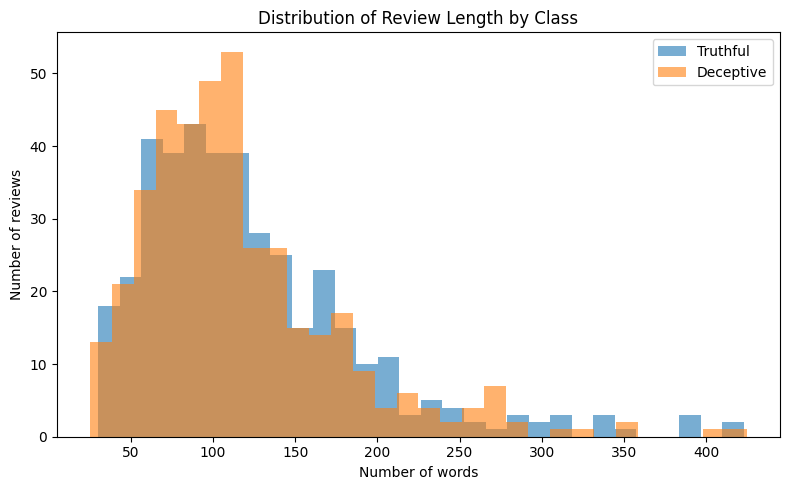

In [ ]:
import matplotlib.pyplot as plt


truthful_lengths = df_clean.loc[
    df_clean["label"] == "truthful",
    "n_words"
]

deceptive_lengths = df_clean.loc[
    df_clean["label"] == "deceptive",
    "n_words"
]


plt.figure(figsize=(8, 5))

plt.hist(
    truthful_lengths,
    bins=30,
    alpha=0.6,
    label="Truthful"
)

plt.hist(
    deceptive_lengths,
    bins=30,
    alpha=0.6,
    label="Deceptive"
)

plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

plt.title(
    "Distribution of Review Length by Class"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    FIGURES_DIR /
    "review_length_distribution.png",
    dpi=300
)
plt.savefig(
    FIGURES_DIR / "review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

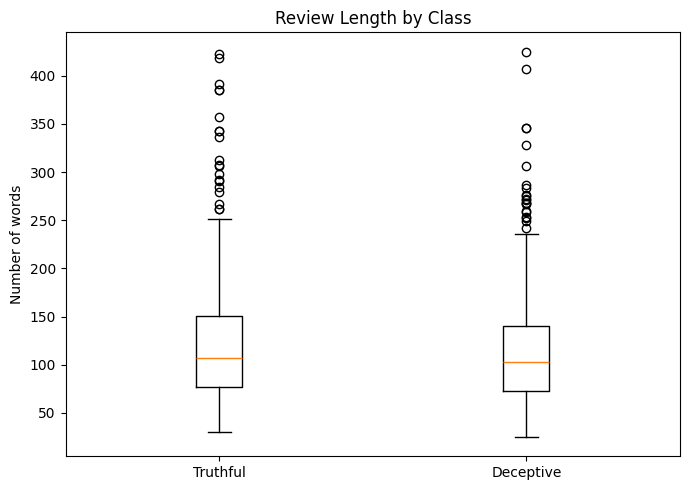

In [ ]:
truthful_lengths = df_clean.loc[
    df_clean["label"] == "truthful",
    "n_words"
]

deceptive_lengths = df_clean.loc[
    df_clean["label"] == "deceptive",
    "n_words"
]


plt.figure(figsize=(7, 5))


plt.boxplot(
    [
        truthful_lengths,
        deceptive_lengths
    ],
    tick_labels=[
        "Truthful",
        "Deceptive"
    ]
)


plt.ylabel("Number of words")

plt.title(
    "Review Length by Class"
)

plt.tight_layout()


plt.savefig(
    FIGURES_DIR /
    "review_length_boxplot.png",
    dpi=300
)

plt.show()

## 11. Review Length Across the Original Folds

In [ ]:
fold_length = (
    df_clean
    .groupby(
        ["fold", "label"]
    )["n_words"]
    .mean()
    .unstack()
)


display(
    fold_length.round(2)
)

label,deceptive,truthful
fold,,
fold1,109.91,120.20
fold2,114.80,126.74
fold3,123.40,134.89
fold4,100.66,121.24
fold5,129.99,112.58


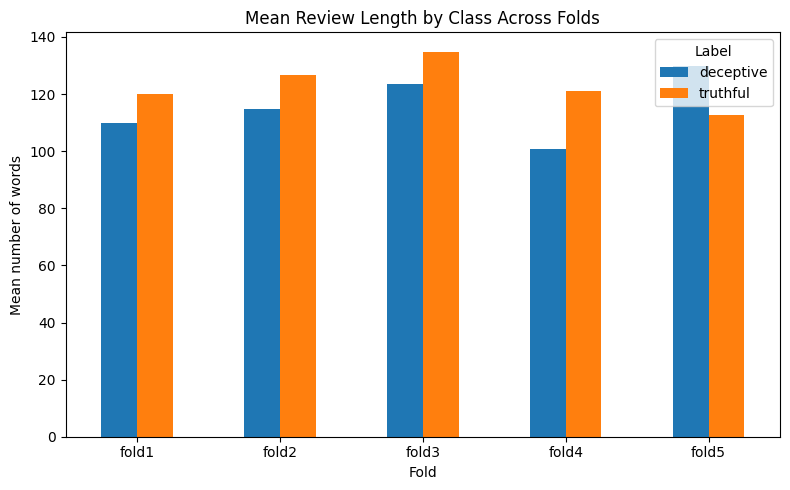

In [ ]:
fold_length.plot(
    kind="bar",
    figsize=(8, 5)
)


plt.xlabel("Fold")
plt.ylabel("Mean number of words")

plt.title(
    "Mean Review Length by Class Across Folds"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Label"
)

plt.tight_layout()


plt.savefig(
    FIGURES_DIR /
    "review_length_by_fold.png",
    dpi=300
)

plt.show()

## 12. Quantify the Difference in Review Length

In [ ]:
mean_truthful = truthful_lengths.mean()

mean_deceptive = deceptive_lengths.mean()


mean_difference = (
    mean_truthful
    - mean_deceptive
)


percentage_difference = (
    mean_difference
    / mean_deceptive
    * 100
)


print(
    "Mean truthful length:",
    round(mean_truthful, 2)
)

print(
    "Mean deceptive length:",
    round(mean_deceptive, 2)
)

print(
    "Difference:",
    round(mean_difference, 2),
    "words"
)

print(
    "Relative difference:",
    round(percentage_difference, 2),
    "%"
)

Mean truthful length: 123.13
Mean deceptive length: 115.75
Difference: 7.38 words
Relative difference: 6.37 %


## 13. Check Review Length Across Hotels

In [ ]:
hotel_length = (
    df_clean
    .groupby(
        ["hotel", "label"]
    )["n_words"]
    .mean()
    .unstack()
)


display(
    hotel_length.round(2)
)

label,deceptive,truthful
hotel,,
affinia,102.90,100.35
allegro,131.60,112.95
amalfi,145.80,111.50
ambassador,119.90,142.30
conrad,110.50,122.70
fairmont,127.95,135.15
hardrock,130.10,146.85
hilton,87.60,128.40
homewood,106.15,114.10


## 14. Create a Balanced Sample for Manual Corpus Inspection

In [ ]:
manual_sample = (
    df_clean
    .groupby(
        ["fold", "label"],
        group_keys=False
    )
    .sample(
        n=2,
        random_state=RANDOM_SEED
    )
    .sample(
        frac=1,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)


print(
    "Number of sampled reviews:",
    len(manual_sample)
)


display(
    pd.crosstab(
        manual_sample["fold"],
        manual_sample["label"]
    )
)

Number of sampled reviews: 20


label,deceptive,truthful
fold,,
fold1,2,2
fold2,2,2
fold3,2,2
fold4,2,2
fold5,2,2


## 15. Manual Inspection of 20 Reviews

In [ ]:
for index, row in manual_sample.iterrows():

    print("=" * 80)

    print(
        f"Review {index + 1} | "
        f"ID: {row['review_id']} | "
        f"Hotel: {row['hotel']} | "
        f"Fold: {row['fold']} | "
        f"Words: {row['n_words']}"
    )

    print()

    print(
        row["text"]
    )

    print()

Review 1 | ID: R0670 | Hotel: james | Fold: fold1 | Words: 118

I am often traveling on business and I always try to stay at the James. The modern design of the lobby and restaurant with wood and glass creates a luxurious atmosphere and the streamlined, comfortable room design give an upscale aesthetic like that of a penthouse loft apartment. The availability of computers and coffee in the James' business centers means I do not have to lug my laptop around the hotel. The James provides the perfect setting for business travelers and is a cozy place to retire to in the evenings. The ease of breakfast service in the rooms means that I do not have to stress or rush, as my time is valuable. I love the James.


Review 2 | ID: R0749 | Hotel: allegro | Fold: fold5 | Words: 203

My husband and I stayed at the Hotel Allegro Chicago to celebrate our 2nd wedding anniversary this past weekend. The hotel is the perfect combination of sophistication and glamour from the moment you arrive. The concier

## 16. Save the Final  Outputs

In [ ]:
CLEAN_DATASET_PATH = (
    PROCESSED_DATA_DIR /
    "positive_deceptive_reviews_clean.csv"
)


MANUAL_SAMPLE_PATH = (
    SAMPLES_DIR /
    "day1_manual_sample.csv"
)


df_clean.to_csv(
    CLEAN_DATASET_PATH,
    index=False
)


manual_sample.to_csv(
    MANUAL_SAMPLE_PATH,
    index=False
)


print("Clean dataset saved at:")
print(CLEAN_DATASET_PATH)


print("\nManual sample saved at:")
print(MANUAL_SAMPLE_PATH)

Clean dataset saved at:
/content/drive/MyDrive/HLT_project/data/processed/positive_deceptive_reviews_clean.csv

Manual sample saved at:
/content/drive/MyDrive/HLT_project/samples/day1_manual_sample.csv


## 17. Final Check


In [ ]:
# Reload the saved file from Google Drive.
final_dataset = pd.read_csv(
    CLEAN_DATASET_PATH
)


assert (
    final_dataset.shape == (800, 8)
)

assert (
    final_dataset["text"]
    .duplicated()
    .sum()
    == 0
)

assert (
    final_dataset
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    final_dataset["hotel"].nunique()
    == 20
)

assert (
    final_dataset["fold"].nunique()
    == 5
)


print("DAY 1 COMPLETED SUCCESSFULLY")
print("-" * 40)

print(
    "Dataset shape:",
    final_dataset.shape
)

print(
    "Hotels:",
    final_dataset["hotel"].nunique()
)

print(
    "Folds:",
    final_dataset["fold"].nunique()
)

print("\nLabels:")

print(
    final_dataset[
        "label"
    ].value_counts()
)

print(
    "\nMissing values:",
    final_dataset.isna().sum().sum()
)

print(
    "Duplicated texts:",
    final_dataset["text"]
    .duplicated()
    .sum()
)

DAY 1 COMPLETED SUCCESSFULLY
----------------------------------------
Dataset shape: (800, 8)
Hotels: 20
Folds: 5

Labels:
label
truthful     400
deceptive    400
Name: count, dtype: int64

Missing values: 0
Duplicated texts: 0
